In [1]:
from utils.DataPreprocessing import dataloader
from loguru import logger
import os

path = os.path.dirname(os.path.dirname(os.getcwd()))
print(path)
data = dataloader(path=path)

2024-03-07 00:43:42.854 | INFO     | utils.DataPreprocessing:load_csv:123 - shape: (11_103, 3)
┌───────────┬─────────────┬────────────┐
│ AVG_TEMP  ┆ AVG_TEMP_DC ┆ date       │
│ ---       ┆ ---         ┆ ---        │
│ f32       ┆ str         ┆ date       │
╞═══════════╪═════════════╪════════════╡
│ 29.299999 ┆ C           ┆ 1992-07-01 │
│ 29.200001 ┆ C           ┆ 1992-07-02 │
│ 29.6      ┆ C           ┆ 1992-07-03 │
│ 29.299999 ┆ C           ┆ 1992-07-04 │
│ 29.299999 ┆ C           ┆ 1992-07-05 │
│ …         ┆ …           ┆ …          │
│ 22.200001 ┆ C           ┆ 2022-11-26 │
│ 22.4      ┆ C           ┆ 2022-11-27 │
│ 25.4      ┆ C           ┆ 2022-11-28 │
│ 25.1      ┆ C           ┆ 2022-11-29 │
│ 22.1      ┆ C           ┆ 2022-11-30 │
└───────────┴─────────────┴────────────┘
2024-03-07 00:43:42.856 | INFO     | utils.DataPreprocessing:load_csv:125 - shape: (1, 3)
┌──────────┬─────────────┬──────┐
│ AVG_TEMP ┆ AVG_TEMP_DC ┆ date │
│ ---      ┆ ---         ┆ ---  │
│ u32      ┆ u32

/home/argonaut/programming/Global-Solar-Radiation-in-King-s-Park


In [2]:
logger.success(data.X_train)
logger.success(data.y_train)
logger.success(data.X_test)
logger.success(data.y_test)

2024-03-07 00:43:42.987 | SUCCESS  | __main__:<module>:1 - shape: (5_441, 34)
┌───────────┬─────┬──────┬─────┬───┬──────────────┬──────────────┬──────────────┬──────────────┐
│ GSR       ┆ SUN ┆ RH   ┆ UV  ┆ … ┆ AVG_TEMP_t-4 ┆ AVG_TEMP_t-3 ┆ AVG_TEMP_t-2 ┆ AVG_TEMP_t-1 │
│ ---       ┆ --- ┆ ---  ┆ --- ┆   ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│ f32       ┆ f32 ┆ f32  ┆ f32 ┆   ┆ f32          ┆ f32          ┆ f32          ┆ f32          │
╞═══════════╪═════╪══════╪═════╪═══╪══════════════╪══════════════╪══════════════╪══════════════╡
│ 16.440001 ┆ 6.9 ┆ 75.0 ┆ 4.0 ┆ … ┆ 28.799999    ┆ 29.0         ┆ 29.299999    ┆ 30.299999    │
│ 1.93      ┆ 0.0 ┆ 79.0 ┆ 0.6 ┆ … ┆ 29.0         ┆ 29.299999    ┆ 30.299999    ┆ 29.299999    │
│ 3.04      ┆ 0.0 ┆ 92.0 ┆ 1.0 ┆ … ┆ 29.299999    ┆ 30.299999    ┆ 29.299999    ┆ 25.9         │
│ 4.34      ┆ 0.0 ┆ 91.0 ┆ 1.0 ┆ … ┆ 30.299999    ┆ 29.299999    ┆ 25.9         ┆ 24.1         │
│ 2.04      ┆ 0.0 ┆ 93.0 ┆ 0.5 ┆ … ┆ 29.299999   

In [3]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

reg = xgb.XGBRegressor(base_score=0.5, 
                       booster='gbtree',    
                     # n_estimators=1000,
                     # early_stopping_rounds=50,
                     objective='reg:squarederror',
                     # max_depth=3,
                     # learning_rate=0.01, 
                     tree_method = "hist", 
                     device = "cuda")

# set up our search grid
param_grid = {"max_depth": list(range(3, 5, 1)), # 4
              "n_estimators": list(range(700, 1000, 100)), # 900
              "learning_rate": [0.015, 0.02, 0.025], # 0.02
              "min_child_weight": [5, 7, 9], # 5
              }

# search = GridSearchCV(reg, param_grid, cv=5, verbose=100).fit(x_train, y_train)

# print("The best hyperparameters are ",search.best_params_)

In [4]:
# reg:xgb.XGBRegressor=xgb.XGBRegressor(learning_rate = search.best_params_["learning_rate"],
#                                    n_estimators = search.best_params_["n_estimators"],
#                                    max_depth = search.best_params_["max_depth"],
#                                    early_stopping_rounds=50,
#                                    objective='reg:squarederror',
#                                    base_score=0.5, 
#                                    booster='gbtree',)

reg:xgb.XGBRegressor=xgb.XGBRegressor(learning_rate = 0.02,
                                        n_estimators = 900,
                                        max_depth = 4,
                                        early_stopping_rounds=50,
                                        objective='reg:squarederror',
                                        base_score=0.5, 
                                        min_child_weight = 5,
                                        booster='gbtree',
                                        tree_method = "hist", 
                                        device = "cuda")

In [5]:
from skforecast.ForecasterAutoreg import ForecasterAutoreg
import pandas as pd
lag = 3
forecaster = ForecasterAutoreg(regressor=reg, 
                                     lags=lag)

print(data.y_train.to_pandas())
forecaster.fit(y=data.y_train.to_pandas())

predictions = forecaster.predict(steps=5)

0       29.299999
1       25.900000
2       24.100000
3       24.900000
4       25.000000
          ...    
5436    30.700001
5437    29.700001
5438    28.799999
5439    29.799999
5440    29.799999
Name: AVG_TEMP, Length: 5441, dtype: float32


ValueError: Must have at least 1 validation dataset for early stopping.

In [ ]:
reg.fit(data.X_train, data.y_train,
        eval_set=[(data.X_train, data.y_train), (data.X_val, data.y_val)],
        verbose=100)

[0]	validation_0-rmse:22.69027	validation_1-rmse:22.93552
[100]	validation_0-rmse:3.24568	validation_1-rmse:3.36482
[200]	validation_0-rmse:1.04862	validation_1-rmse:1.20779
[300]	validation_0-rmse:0.89219	validation_1-rmse:1.07158
[400]	validation_0-rmse:0.85112	validation_1-rmse:1.05164
[500]	validation_0-rmse:0.81847	validation_1-rmse:1.04072
[600]	validation_0-rmse:0.78809	validation_1-rmse:1.03236
[700]	validation_0-rmse:0.76344	validation_1-rmse:1.02787
[800]	validation_0-rmse:0.74358	validation_1-rmse:1.02502
[899]	validation_0-rmse:0.72544	validation_1-rmse:1.02304


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.02, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=900, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

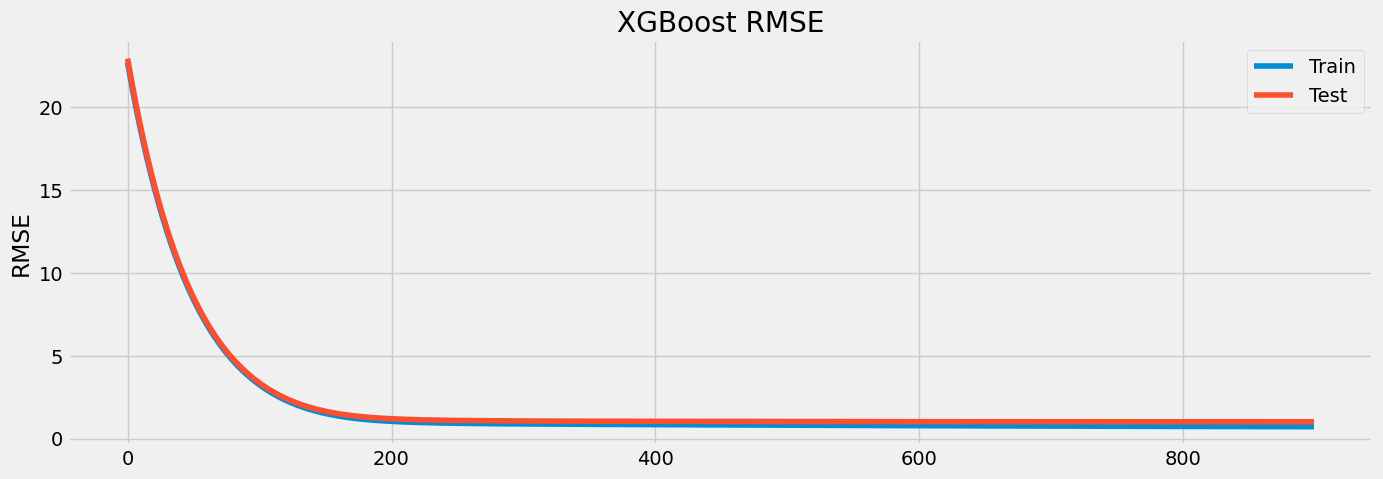

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
# plot the loss
results = reg.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(x_axis, results['validation_0']['rmse'], label='Train')
ax.plot(x_axis, results['validation_1']['rmse'], label='Test')
ax.legend()
plt.ylabel('RMSE')
plt.title('XGBoost RMSE')
plt.show()

In [ ]:
# Predict the values
y_train_pred = reg.predict(data.X_train)
y_test_pred = reg.predict(data.X_test)

# Calculate R^2 scores
r2_train = r2_score(data.y_train, y_train_pred)
r2_test = r2_score(data.y_test, y_test_pred)

# # Plot R^2 scores
# plt.figure(figsize=(10, 6))
# plt.bar(['Train', 'Test'], [r2_train, r2_test])
# plt.title('R^2 Scores for Train and Test Sets')
# plt.ylabel('R^2 Score')
# plt.show()

print("R^2 score for train set: ", r2_train)
print("R^2 score for test set: ", r2_test)

R^2 score for train set:  0.9801754730511892
R^2 score for test set:  0.9603818785360271


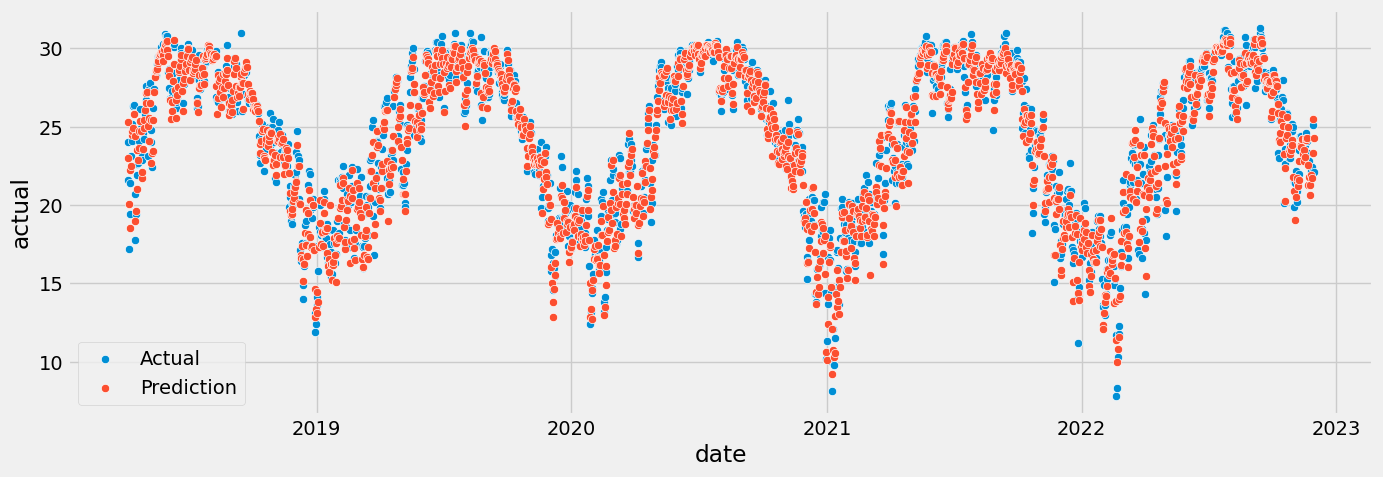

In [ ]:
from polars import DataFrame
import seaborn as sns

def plot_predictions(testing_dates, y_test, prediction):
  fig, ax = plt.subplots(figsize=(15, 5),)
  df_test = DataFrame({"date": testing_dates, "actual": y_test, "prediction": prediction })
  date_col = "date"
  data_col = df_test.columns[1]  # Assuming the first column is 'date'
  plot_data = df_test[[date_col, data_col]]
  sns.scatterplot(x=date_col, y=data_col, data=plot_data)
  
  data_col = df_test.columns[2]
  plot_data = df_test[[date_col, data_col]]
  sns.scatterplot(x=date_col, y=data_col, data=plot_data)
  
  plt.legend(["Actual", "Prediction"])
  plt.show()

plot_predictions(data.date_test, data.y_test, y_test_pred)
# plot_predictions(x_test.index[-10:], y_test[-10:], y_test_pred[-10:])